# Capstone Project Janet Beaton

## Applied Python for Data Analysis 

## Capstone Project - 5/20/2026

### Problem Statement
Using data from Inside Airbnb, this project will analyze which Airbnb listing features and neighborhood locations have the greatest influence on nightly rental prices in order to help potential real estate investors identify the most profitable types of properties and areas for Airbnb investment.

### Audience

My small set of investers are looking for property in Denver to buy.

### Primary Business / Analytical Question

How can we make the most amount of money?



In [32]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# File path tools
from pathlib import Path


In [33]:
RAW = Path("..\data") / "raw"
PROCESSED = Path("..\data") / "processed"
image_path = Path("..\outputs")

In [34]:
listings=pd.read_csv(RAW / "listings.csv")
#I looked at the two data sets, the smaller and the larger and i decided to go with the larger
#- "listings" has 4910 with 79 columns, integer, float and string types. 
#Some columns have as few as 2738 rows, but thats ok, i probalby own't use the description and neighborhood overview.

In [35]:
# Shape of the dataset
listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4910 entries, 0 to 4909
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            4910 non-null   int64  
 1   listing_url                                   4910 non-null   object 
 2   scrape_id                                     4910 non-null   int64  
 3   last_scraped                                  4910 non-null   object 
 4   source                                        4910 non-null   object 
 5   name                                          4910 non-null   object 
 6   description                                   4859 non-null   object 
 7   neighborhood_overview                         2738 non-null   object 
 8   picture_url                                   4910 non-null   object 
 9   host_id                                       4910 non-null   i

In [36]:
# the data cut-off is 30 September 2025
listings['last_scraped'].value_counts()

last_scraped
2025-09-30    4872
2025-09-29      38
Name: count, dtype: int64

In [37]:
#are the review scores any different?  should i get rid of more columns?
reviews=['id', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value']

listings[reviews].describe()

#they look all the same std was between .23 and .31 - just keep one review score - the largest std dev. is review_scores_value

,id,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
count,4.910000e+03,4302.000000,4302.000000,4302.000000,4302.000000,4302.000000,4302.000000,4302.000000
mean,6.324804e+17,4.862480,4.879147,4.843570,4.914433,4.912487,4.851492,4.781825
std,5.587634e+17,0.278913,0.261971,0.308679,0.228211,0.257803,0.267801,0.316445
min,3.600000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,4.382275e+07,4.840000,4.860000,4.820000,4.910000,4.920000,4.810000,4.740000
50%,7.322467e+17,4.940000,4.950000,4.930000,4.970000,4.980000,4.920000,4.860000
75%,1.130367e+18,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.940000
max,1.519943e+18,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [38]:
# i need to narrow down my data columns to a reasonable amount.
# cols_to_drop = [1-8,10-17, 19-27, 29, 41-46, 63, 64, 72-78]
cols_to_drop = (
    list(range(1, 9)) +
    list(range(10, 18)) +
    list(range(19, 28)) +
    list(range(38, 40)) +
    list(range(41, 61)) +
    list(range(63, 71)) +
    list(range(72, 79)) +
    [29, 36]
)
df = listings.drop(listings.columns[cols_to_drop], axis=1)

In [39]:
numeric_cols = df.select_dtypes(include='number').columns
categorical_cols = df.select_dtypes(exclude='number').columns
# Column names
print('Numeric columns:', list(numeric_cols))
print('Categorical columns:', list(categorical_cols))


Numeric columns: ['id', 'host_id', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'review_scores_value']
Categorical columns: ['host_is_superhost', 'neighbourhood_cleansed', 'property_type', 'room_type', 'price']


In [40]:
# Summary statistics for non-numeric columns
for value in categorical_cols:
    print(df[value].value_counts(normalize=True)*100)
    print()

host_is_superhost
t    57.552902
f    42.447098
Name: proportion, dtype: float64

neighbourhood_cleansed
Five Points                     8.431772
Highland                        5.539715
Union Station                   4.317719
West Colfax                     4.215886
Gateway - Green Valley Ranch    3.930754
                                  ...   
Auraria                         0.101833
Marston                         0.101833
Wellshire                       0.101833
Sun Valley                      0.020367
Kennedy                         0.020367
Name: proportion, Length: 78, dtype: float64

property_type
Entire home                           32.403259
Entire rental unit                    18.268839
Entire condo                           9.816701
Private room in home                   8.228106
Entire guest suite                     7.718941
Entire townhouse                       7.148676
Entire guesthouse                      5.865580
Entire loft                            1.405295


In [41]:
# Summary statistics for numeric columns
df.describe()

,id,host_id,latitude,longitude,accommodates,bathrooms,bedrooms,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_value
count,4.910000e+03,4.910000e+03,4910.000000,4910.000000,4910.000000,4302.000000,4828.000000,4910.000000,4301.00000,4302.000000
mean,6.324804e+17,1.611976e+08,39.742119,-104.976266,4.148676,1.524872,1.809859,109.487576,17227.11974,4.781825
std,5.587634e+17,1.810321e+08,0.031679,0.061599,2.656296,0.918542,1.126130,97.110779,20762.93897,0.316445
min,3.600000e+02,5.890000e+02,39.624950,-105.102804,1.000000,0.000000,0.000000,0.000000,0.00000,1.000000
25%,4.382275e+07,2.369901e+07,39.728243,-105.017105,2.000000,1.000000,1.000000,0.000000,1498.00000,4.740000
50%,7.322467e+17,7.903728e+07,39.748155,-104.984857,4.000000,1.000000,2.000000,91.000000,12470.00000,4.860000
75%,1.130367e+18,2.469210e+08,39.762538,-104.959497,6.000000,2.000000,2.000000,203.000000,25245.00000,4.940000
max,1.519943e+18,7.205757e+08,39.847417,-104.673817,16.000000,17.000000,10.000000,255.000000,254745.00000,5.000000


In [42]:
# Data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4910 entries, 0 to 4909
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         4910 non-null   int64  
 1   host_id                    4910 non-null   int64  
 2   host_is_superhost          4773 non-null   object 
 3   neighbourhood_cleansed     4910 non-null   object 
 4   latitude                   4910 non-null   float64
 5   longitude                  4910 non-null   float64
 6   property_type              4910 non-null   object 
 7   room_type                  4910 non-null   object 
 8   accommodates               4910 non-null   int64  
 9   bathrooms                  4302 non-null   float64
 10  bedrooms                   4828 non-null   float64
 11  price                      4301 non-null   object 
 12  estimated_occupancy_l365d  4910 non-null   int64  
 13  estimated_revenue_l365d    4301 non-null   float

In [43]:
# Missing values by column
df.isna().sum()

id                             0
host_id                        0
host_is_superhost            137
neighbourhood_cleansed         0
latitude                       0
longitude                      0
property_type                  0
room_type                      0
accommodates                   0
bathrooms                    608
bedrooms                      82
price                        609
estimated_occupancy_l365d      0
estimated_revenue_l365d      609
review_scores_value          608
dtype: int64

In [44]:
# Duplicate rows

df.duplicated().sum()

np.int64(0)

## 6. Data Cleaning

Use this section to clean your dataset.

Common cleaning tasks:
- Fix column names
- Convert data types
- Handle missing values
- Remove duplicates
- Fix inconsistent categories
- Create helpful new columns

Document every major cleaning decision in markdown.


In [45]:
# Make a copy before cleaning
df_original=df.copy()

In [46]:
df.head()

,id,host_id,host_is_superhost,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,price,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_value
0,360,666,t,Highland,39.766415,-105.002098,Entire guesthouse,Entire home/apt,2,1.0,2.0,$139.00,174,24186.0,4.90
1,364,783,f,Five Points,39.766720,-104.979060,Entire loft,Entire home/apt,3,1.5,1.0,$213.00,0,0.0,4.71
2,592,933,t,North Park Hill,39.754810,-104.911060,Private room in home,Private room,2,1.0,1.0,$46.00,175,8050.0,4.88
3,686,990,t,North Capitol Hill,39.746950,-104.978380,Private room in home,Private room,1,1.0,1.0,$40.00,120,4800.0,4.82
4,1940,2150,t,Baker,39.720205,-104.997499,Entire guesthouse,Entire home/apt,2,1.0,0.0,$87.00,255,22185.0,4.90


In [47]:
# make all empty superhosts as false
df["host_is_superhost"] = df["host_is_superhost"].fillna("f")
# data not useful if it doesn't have a price - fix it so i can use it as a number
df = df.dropna(subset=['price'])
df['price'] = (
    df['price']
    .replace('[$,]', '', regex=True)
    .astype(float)
)
# beadrooms column wasn't helpful - i can capture that info with accomodates
df = df.dropna(subset=['bedrooms'])

#zero or less than 10 night occupancy i won't consider valuable
df = df[df['estimated_occupancy_l365d'] > 10]

In [48]:
# i want to remove the rentals that are WAY too expensive - 
#i decided paying 5x above the 75% percentile was WAY above the threshold
# may consider even lower later?
q1 = df["price"].quantile(0.25)
q3 = df["price"].quantile(0.75)
# calculate our interquartile range
iqr = q3 - q1
lower_bound = 10
upper_bound = q3 + 5*iqr
price_outliers = df[
    (df["price"] < lower_bound) |
    (df["price"] > upper_bound)
]
price_outliers.describe()

,id,host_id,latitude,longitude,accommodates,bathrooms,bedrooms,price,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_value
count,3.800000e+01,3.800000e+01,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000
mean,4.951162e+17,1.631327e+08,39.744797,-104.992219,10.526316,3.697368,4.289474,1064.078947,106.052632,98671.184211,4.787632
std,5.435992e+17,1.839242e+08,0.028748,0.026956,4.098364,1.883569,2.116957,704.039057,84.430348,73060.235098,0.168578
min,7.228382e+06,1.731643e+06,39.669543,-105.036151,3.000000,1.000000,0.000000,678.000000,14.000000,11046.000000,4.330000
25%,4.067079e+07,3.357033e+07,39.740781,-105.008168,8.000000,2.000000,3.000000,836.750000,38.500000,47187.000000,4.712500
50%,2.919779e+17,8.856686e+07,39.756060,-104.993002,10.000000,4.000000,4.500000,924.000000,75.000000,72502.500000,4.860000
75%,8.683045e+17,2.224868e+08,39.760728,-104.971998,14.000000,4.500000,6.000000,999.000000,145.500000,136582.250000,4.900000
max,1.427116e+18,6.812801e+08,39.790000,-104.913200,16.000000,10.500000,10.000000,5000.000000,255.000000,254745.000000,5.000000


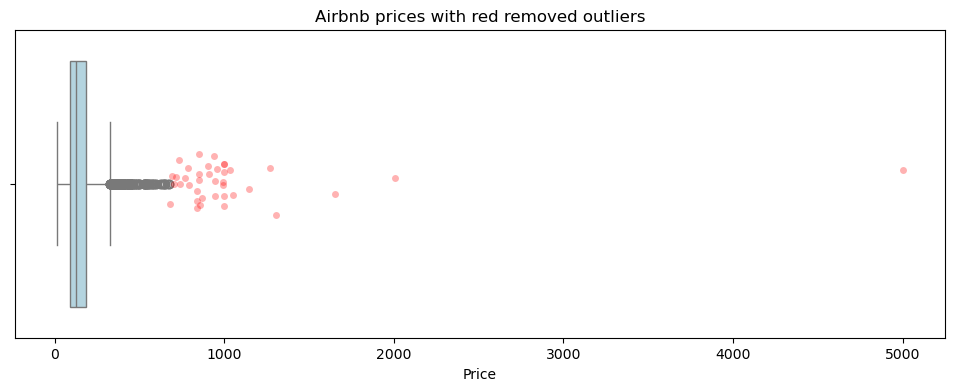

In [74]:
plt.figure(figsize=(12, 4))
sns.boxplot(
    x=df["price"],
    color="lightblue"
)
sns.stripplot(
    x=price_outliers["price"],
    color="red",
    alpha=0.3
)
plt.title("Airbnb prices with red removed outliers")
plt.xlabel("Price")

plt.savefig(
    image_path / "pricesRaw.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
#  this gives me a visual of the outliers i removed.  
#i still have too many that are a VERY high price

In [50]:
df = df.drop(price_outliers.index)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3188 entries, 0 to 4875
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         3188 non-null   int64  
 1   host_id                    3188 non-null   int64  
 2   host_is_superhost          3188 non-null   object 
 3   neighbourhood_cleansed     3188 non-null   object 
 4   latitude                   3188 non-null   float64
 5   longitude                  3188 non-null   float64
 6   property_type              3188 non-null   object 
 7   room_type                  3188 non-null   object 
 8   accommodates               3188 non-null   int64  
 9   bathrooms                  3188 non-null   float64
 10  bedrooms                   3188 non-null   float64
 11  price                      3188 non-null   float64
 12  estimated_occupancy_l365d  3188 non-null   int64  
 13  estimated_revenue_l365d    3188 non-null   float64
 1

In [52]:
# TODO: Check categorical columns for inconsistent labels
numeric_cols = df.select_dtypes(include='number').columns
categorical_cols = df.select_dtypes(exclude='number').columns
print('Numeric columns:', list(numeric_cols))
print('Categorical columns:', list(categorical_cols))
for value in categorical_cols:
    print(df[value].value_counts(normalize=True)*100)
    print()

Numeric columns: ['id', 'host_id', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'price', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'review_scores_value']
Categorical columns: ['host_is_superhost', 'neighbourhood_cleansed', 'property_type', 'room_type']
host_is_superhost
t    67.848181
f    32.151819
Name: proportion, dtype: float64

neighbourhood_cleansed
Five Points                    8.469260
Highland                       6.461731
West Colfax                    4.203262
Union Station                  4.109159
Berkeley                       3.858218
                                 ...   
College View - South Platte    0.125471
Lowry Field                    0.094103
Fort Logan                     0.094103
Indian Creek                   0.031368
Southmoor Park                 0.031368
Name: proportion, Length: 76, dtype: float64

property_type
Entire home                          30.803011
Entire rental unit                   17.879548
Entire guest 

In [53]:
# instead of how many days of occupancy, lets do a rate.  
# since the greatest number of days was 255, i made that my 100% occupancy

df["occupancy_percent"] = df["estimated_occupancy_l365d"] / 255*100
df.head()

,id,host_id,host_is_superhost,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,price,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_value,occupancy_percent
0,360,666,t,Highland,39.766415,-105.002098,Entire guesthouse,Entire home/apt,2,1.0,2.0,139.0,174,24186.0,4.90,68.235294
2,592,933,t,North Park Hill,39.754810,-104.911060,Private room in home,Private room,2,1.0,1.0,46.0,175,8050.0,4.88,68.627451
3,686,990,t,North Capitol Hill,39.746950,-104.978380,Private room in home,Private room,1,1.0,1.0,40.0,120,4800.0,4.82,47.058824
4,1940,2150,t,Baker,39.720205,-104.997499,Entire guesthouse,Entire home/apt,2,1.0,0.0,87.0,255,22185.0,4.90,100.000000
5,31503,135298,t,West Highland,39.761790,-105.028450,Entire guest suite,Entire home/apt,2,1.0,1.0,77.0,120,9240.0,4.87,47.058824


### Cleaning Summary
 
##### I made all the empty superhosts as false - don't want to overstate how many superhosts there were and would rather underestimate their importance
##### the number of beadrooms column wasn't helpful - i will use the accomodates column
##### zero or less than 10 night occupancy i won't consider valuable
##### I removed the rentals that are WAY too expensive - i decided paying 5x above the 75% percentile was WAY above the threshold 

## 7. Exploratory Data Analysis


### 7.1 Univariate Analysis


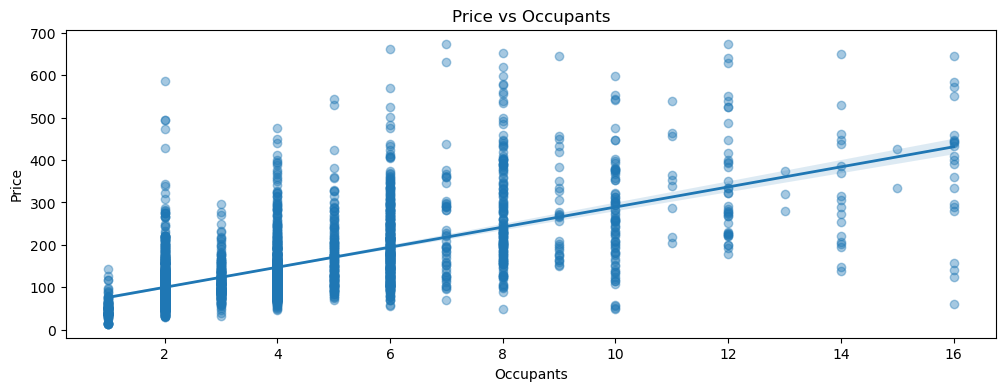

In [54]:
#lets see how the price varies based on occupants
plt.figure(figsize=(12, 4))

sns.regplot(
    data=df,
    x="accommodates",
    y="price",
    scatter_kws={"alpha":0.4},
    line_kws={"linewidth":2}
)

plt.title("Price vs Occupants")
plt.xlabel("Occupants")
plt.ylabel("Price")

plt.show()
# The scatterplot gives me an idea how the price goes up with the number of occupants.  
# The linear regression helps see their IS a strong positive linear relationship between them.

#  the number of occupants do NOT dictate the price

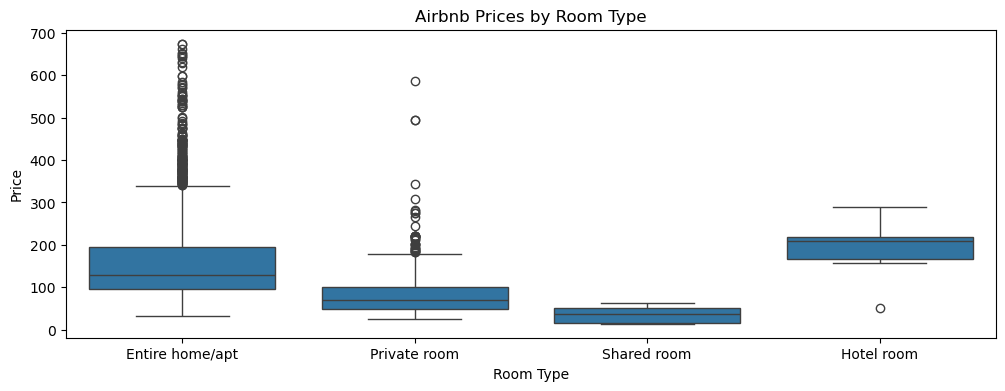

In [55]:
# TODO: Choose a categorical column to visualize
plt.figure(figsize=(12, 4))

sns.boxplot(
    data=df,
    x="room_type",
    y="price",)

plt.title("Airbnb Prices by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price")

plt.show()
#The box plot shows that entire homes generally have higher median prices 
# and more variability compared to private or shared rooms.
#The wiskers show the variablility in each - the home/apt has some VERY high prices.

### 7.2 Group-Based Analysis


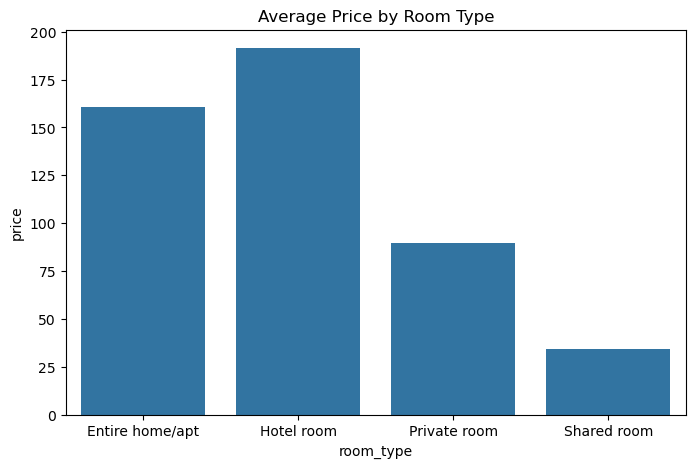

In [56]:
room_price = df.groupby("room_type")["price"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=room_price, x="room_type", y="price")

plt.title("Average Price by Room Type")
plt.show()
# wow.  hotel room average is HIGH - but maybe i don't have a large enough sample size?

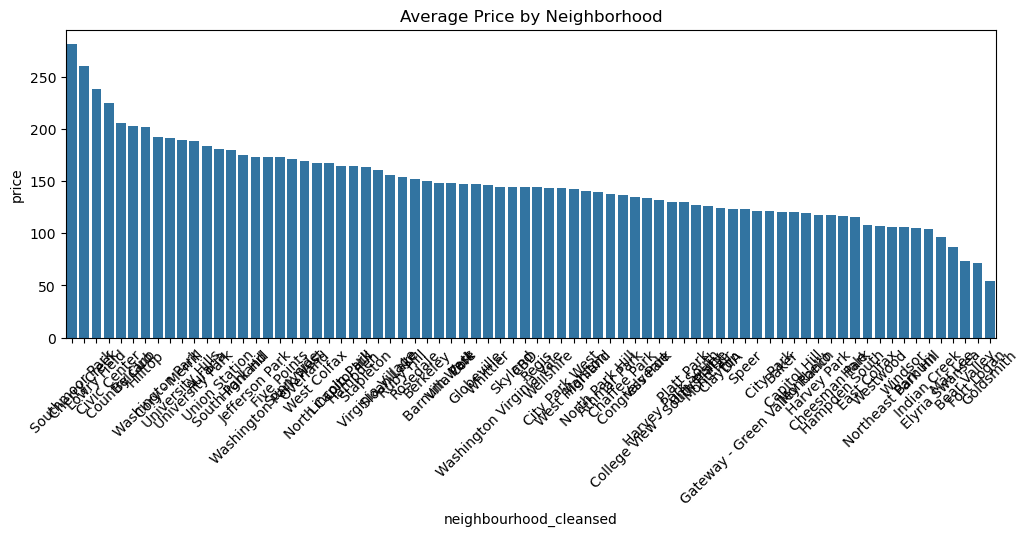

In [57]:
neigh_price = df.groupby("neighbourhood_cleansed")["price"].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12,4))
sns.barplot(data=neigh_price, x="neighbourhood_cleansed", y="price")

plt.xticks(rotation=45)
plt.title("Average Price by Neighborhood")
plt.show()
# Clearly we should invest in the neighborhoods on the higher end of price

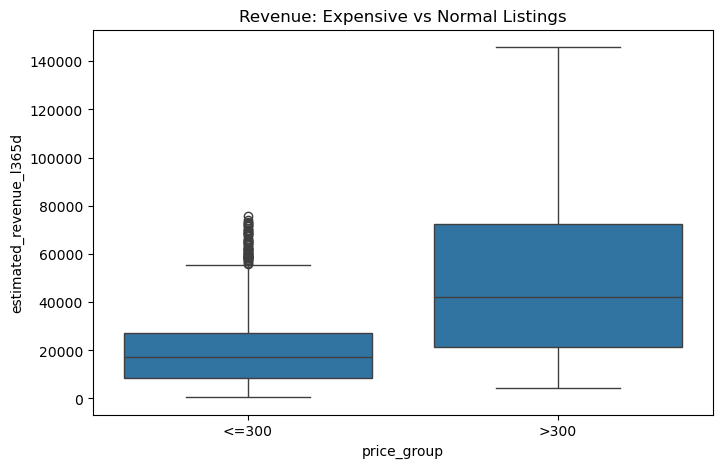

In [60]:
#Lets explore - are the most expensive rentals (above $300) actually making $$?
df["price_group"] = df["price"].apply(lambda x: ">300" if x > 300 else "<=300")

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="price_group",
    y="estimated_revenue_l365d"
)

plt.title("Revenue: Expensive vs Normal Listings")

plt.savefig(
    image_path / "twoPriceGroups_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [72]:
#lets look at the price group below $300, but the estimated revenue greater than $30,000, that looks like a nice group to focus on

df_filter = df[
    (df["price"] < 300) &
    (df["estimated_revenue_l365d"] >= 30000)
]
df_filter.to_csv(PROCESSED / "filtered_data.csv", index=False)
df_filter.describe()

,id,host_id,latitude,longitude,accommodates,bathrooms,bedrooms,price,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_value,occupancy_percent
count,6.070000e+02,6.070000e+02,607.000000,607.000000,607.000000,607.000000,607.000000,607.000000,607.000000,607.000000,607.000000,607.000000
mean,6.267118e+17,1.644686e+08,39.746067,-104.982404,5.172982,1.635091,2.121911,185.019769,229.355848,41287.942339,4.835815,89.943470
std,5.050451e+17,1.756139e+08,0.027452,0.057186,2.564301,0.783412,1.072441,49.902310,39.459532,9993.748773,0.135480,15.474326
min,3.940500e+04,6.660000e+02,39.647020,-105.058589,1.000000,1.000000,0.000000,118.000000,105.000000,30000.000000,4.000000,41.176471
25%,4.626622e+07,2.858955e+07,39.734195,-105.018197,4.000000,1.000000,1.000000,142.000000,210.000000,33660.000000,4.790000,82.352941
50%,7.520182e+17,9.235646e+07,39.750730,-104.987320,4.000000,1.000000,2.000000,176.000000,255.000000,38024.000000,4.870000,100.000000
75%,1.094066e+18,2.245117e+08,39.763110,-104.971090,6.000000,2.000000,3.000000,218.000000,255.000000,46155.000000,4.920000,100.000000
max,1.440570e+18,6.746422e+08,39.818251,-104.737700,16.000000,4.500000,5.000000,299.000000,255.000000,75735.000000,5.000000,100.000000


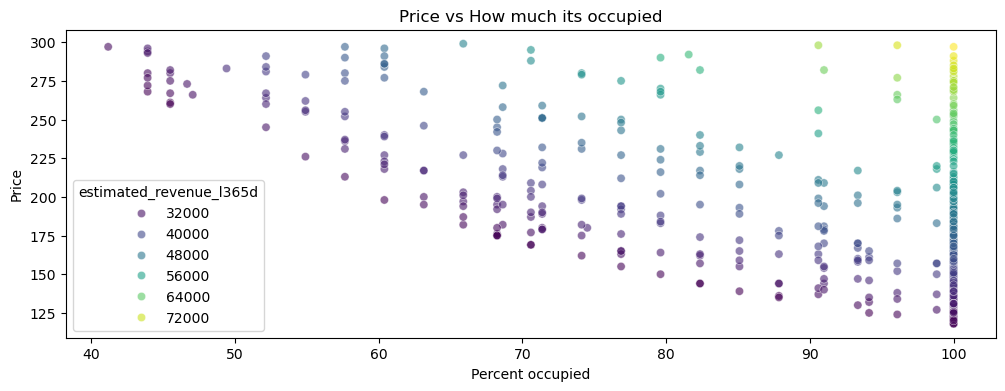

In [62]:
plt.figure(figsize=(12, 4))

sns.scatterplot(
    data=df_filter,
    x="occupancy_percent",
    y="price",
    hue="estimated_revenue_l365d",
    palette="viridis",
    alpha=0.6
)
plt.title("Price vs How much its occupied")
plt.xlabel("Percent occupied")
plt.ylabel("Price")
plt.savefig(
    image_path / "PriceOccupiedIncome.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
# this is not really surprising - the more its occupied and the higher price is going to get us the most money. 

### 7.3 Relationship Analysis

Explore relationships between variables.

Examples:
- Revenue vs discount
- Sale price vs square footage
- Satisfaction vs return status


In [63]:
df.select_dtypes(include='number').corr()

,id,host_id,latitude,longitude,accommodates,bathrooms,bedrooms,price,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_value,occupancy_percent
id,1.000000,0.264051,-0.005268,0.037120,0.060209,0.068064,0.094185,0.077450,-0.168295,-0.036391,-0.022972,-0.168295
host_id,0.264051,1.000000,0.042256,0.092548,0.010873,0.011168,-0.001060,0.004565,-0.028821,-0.011996,-0.078146,-0.028821
latitude,-0.005268,0.042256,1.000000,0.121484,0.031425,0.030058,-0.000693,0.037334,0.027092,0.054398,0.054080,0.027092
longitude,0.037120,0.092548,0.121484,1.000000,0.077593,0.071749,0.112448,-0.055591,-0.041618,-0.068762,-0.017774,-0.041618
accommodates,0.060209,0.010873,0.031425,0.077593,1.000000,0.649222,0.844662,0.642876,-0.037031,0.463980,0.004245,-0.037031
bathrooms,0.068064,0.011168,0.030058,0.071749,0.649222,1.000000,0.673703,0.603353,-0.130519,0.357373,0.034720,-0.130519
bedrooms,0.094185,-0.001060,-0.000693,0.112448,0.844662,0.673703,1.000000,0.640651,-0.103677,0.410183,0.011352,-0.103677
price,0.077450,0.004565,0.037334,-0.055591,0.642876,0.603353,0.640651,1.000000,-0.139373,0.598649,0.068277,-0.139373
estimated_occupancy_l365d,-0.168295,-0.028821,0.027092,-0.041618,-0.037031,-0.130519,-0.103677,-0.139373,1.000000,0.587518,0.128709,1.000000
estimated_revenue_l365d,-0.036391,-0.011996,0.054398,-0.068762,0.463980,0.357373,0.410183,0.598649,0.587518,1.000000,0.122583,0.587518


In [64]:
affects_money=['host_id','accommodates','bathrooms', "bedrooms", "estimated_occupancy_l365d", "review_scores_value"]
cols = affects_money + ["price", "estimated_revenue_l365d"]
df[cols].corr()
# highest correlations... 
# Price: size followed by estimated revenue
# Estimated revenue: price follwed by estimated occupancy
# if i want to make money i have to have a higher price AND have it occupied.

,host_id,accommodates,bathrooms,bedrooms,estimated_occupancy_l365d,review_scores_value,price,estimated_revenue_l365d
host_id,1.000000,0.010873,0.011168,-0.001060,-0.028821,-0.078146,0.004565,-0.011996
accommodates,0.010873,1.000000,0.649222,0.844662,-0.037031,0.004245,0.642876,0.463980
bathrooms,0.011168,0.649222,1.000000,0.673703,-0.130519,0.034720,0.603353,0.357373
bedrooms,-0.001060,0.844662,0.673703,1.000000,-0.103677,0.011352,0.640651,0.410183
estimated_occupancy_l365d,-0.028821,-0.037031,-0.130519,-0.103677,1.000000,0.128709,-0.139373,0.587518
review_scores_value,-0.078146,0.004245,0.034720,0.011352,0.128709,1.000000,0.068277,0.122583
price,0.004565,0.642876,0.603353,0.640651,-0.139373,0.068277,1.000000,0.598649
estimated_revenue_l365d,-0.011996,0.463980,0.357373,0.410183,0.587518,0.122583,0.598649,1.000000


In [65]:
affects_money=['host_id','accommodates','bathrooms', "bedrooms", "estimated_occupancy_l365d", "review_scores_value"]
cols = affects_money + ["price", "estimated_revenue_l365d"]
df_filter[cols].corr()
# NOw lets look at JUST the filtered data, Highest corelations:
# Price: depends on estimated revenue more than size
# Estimated revenue: HIGH correlation with price
# if i want to make money looking at just my smaller subset,  i have to have a higher price.

,host_id,accommodates,bathrooms,bedrooms,estimated_occupancy_l365d,review_scores_value,price,estimated_revenue_l365d
host_id,1.000000,0.086981,0.094400,0.051947,-0.005816,-0.058620,0.120730,0.135166
accommodates,0.086981,1.000000,0.661096,0.831184,-0.255409,-0.154232,0.448143,0.296607
bathrooms,0.094400,0.661096,1.000000,0.682532,-0.350321,-0.034700,0.541783,0.326231
bedrooms,0.051947,0.831184,0.682532,1.000000,-0.290014,-0.113465,0.481277,0.310519
estimated_occupancy_l365d,-0.005816,-0.255409,-0.350321,-0.290014,1.000000,0.036490,-0.583670,0.233254
review_scores_value,-0.058620,-0.154232,-0.034700,-0.113465,0.036490,1.000000,-0.005985,0.023061
price,0.120730,0.448143,0.541783,0.481277,-0.583670,-0.005985,1.000000,0.640641
estimated_revenue_l365d,0.135166,0.296607,0.326231,0.310519,0.233254,0.023061,0.640641,1.000000


In [66]:
# df_filter.describe()

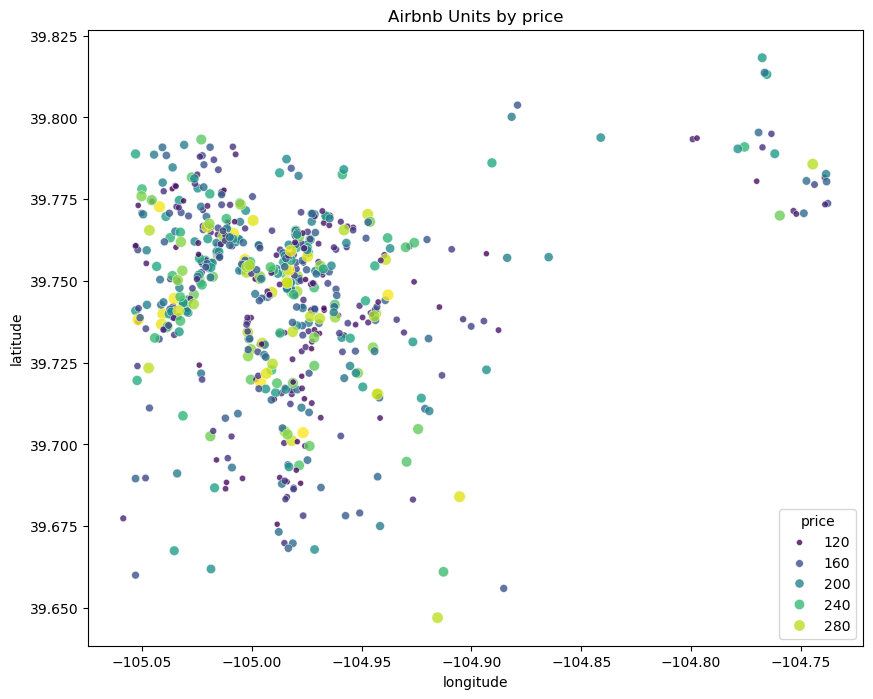

In [67]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=df_filter,
    x="longitude",
    y="latitude",
    hue="price",
    size="price",
    palette="viridis",
    alpha=0.8
)

plt.title("Airbnb Units by price")
plt.show()

# there is a nice scattering of units in the neighborhoods of Denver
# Even though my graph above has the average price per neighborhood, i think this shows
# a good variety of house 

In [73]:
# i'm narrowing down based on reasonable family $300 or lower per night,
# nice revenue greater $50,000 or above, and
# good occupancy rate higher than 75%

df_filter2 = df[
    (df["price"] < 300) &
    (df["estimated_revenue_l365d"] >= 50000) &
    (df["occupancy_percent"] >= 75)]

df_filter2.to_csv(PROCESSED / "filteredx2_data.csv", index=False)

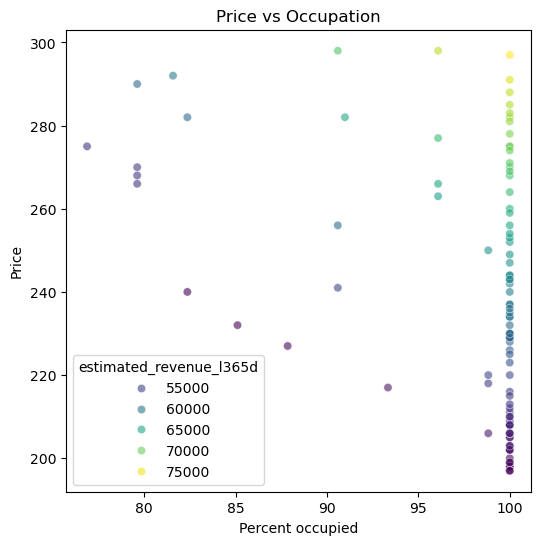

In [77]:
plt.figure(figsize=(6, 6))

sns.scatterplot(
    data=df_filter2,
    x="occupancy_percent",
    y="price",
    hue="estimated_revenue_l365d",
    palette="viridis",
    alpha=0.6
)
plt.title("Price vs Occupation")
plt.xlabel("Percent occupied")
plt.ylabel("Price")
plt.savefig(
    image_path / "PriceOccupiedIncome_narrow.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# this narrows down my data - i show that we can have a minimum revenue while STILL
# having a reasonably priced unit between $200 and $300. Clearly i can have a $200 
# unit if i have it occupied 100%, but that MAY not be reasonable

In [44]:
df_filter2.describe()

,id,host_id,latitude,longitude,accommodates,bathrooms,bedrooms,price,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_value,occupancy_percent
count,1.010000e+02,1.010000e+02,101.000000,101.000000,101.000000,101.000000,101.000000,101.00000,101.000000,101.000000,101.000000,101.000000
mean,6.484695e+17,2.095397e+08,39.751183,-104.975953,6.663366,2.099010,2.752475,239.39604,248.693069,59371.168317,4.850990,97.526694
std,4.992451e+17,1.973806e+08,0.024122,0.066771,2.658109,0.824681,1.023777,29.96000,14.807257,7076.572501,0.097031,5.806767
min,2.975710e+06,1.989602e+06,39.667880,-105.051830,2.000000,1.000000,0.000000,197.00000,196.000000,50235.000000,4.410000,76.862745
25%,5.005303e+07,3.707830e+07,39.740010,-105.017770,5.000000,1.000000,2.000000,210.00000,255.000000,53040.000000,4.810000,100.000000
50%,7.763783e+17,1.233114e+08,39.753140,-104.985023,6.000000,2.000000,3.000000,235.00000,255.000000,58650.000000,4.860000,100.000000
75%,1.095968e+18,4.005025e+08,39.762670,-104.968743,8.000000,2.500000,3.000000,266.00000,255.000000,64515.000000,4.920000,100.000000
max,1.428289e+18,6.736518e+08,39.818251,-104.738482,14.000000,4.500000,5.000000,298.00000,255.000000,75735.000000,5.000000,100.000000


## 8. Insights and Recommendations

### Insight 1

##### Higher price, larger size and higher occupancy will increase the revenue for my investors, but depending on our yearly revenue goals, we can find something that balances all those three.

### Recommendation 1

##### If we want to make money with a family-friendly (under $300) rental, size doesn't matter as much as price of the rental.

### Insight 2

##### In order to make more money, my investors need to focus on the price of the unit.

### Recommendation 2

##### Keep your price above 200, but under $300, you can make over 55,000 a year.  Occupancy will need to be over 80 percent - if we can keep 100% occupancy we can make as much as 75,000


### Final Summary

Using the city of Denver data from Inside Airbnb, https://insideairbnb.com, this project will analyze which Airbnb listing features and neighborhood locations have the greatest influence on nightly rental prices in order to help potential real estate investors identify the most profitable types of properties and areas for Airbnb investment.

The dataset was cleaned by removing unnecessary columns, handling missing values, converting prices to numeric format, and standardizing superhost indicators. Listings with fewer than 10 occupied nights were excluded to better represent properties with meaningful rental activity for investment analysis.

My analysis found that higher nightly prices and stronger occupancy rates are the biggest drivers of Airbnb revenue for investors. For family-friendly rentals under &200 and &55,000 annually, while near-full occupancy could produce up to $75,000 per year. These results suggest investors should focus on strategic pricing and maintaining high occupancy to maximize profitability.

A key limitation of this analysis is that it uses historical Airbnb data, which may not reflect current market conditions or changes in demand over time. Occupancy and revenue are often estimated rather than directly observed, which can introduce some uncertainty. In addition, important factors like property condition, photos, and host quality are not fully captured in the dataset. Finally, the results show correlations rather than true cause-and-effect relationships between price, occupancy, and revenue.

Future work could improve this analysis by incorporating more recent and granular data, including seasonal trends and location-based market conditions. Adding external datasets such as local housing prices, tourism demand, and neighborhood amenities could also improve predictive accuracy. In addition, applying more advanced modeling techniques could help better estimate causal relationships between price, occupancy, and revenue rather than just correlations.

## 12. Final Notebook Checklist

Before submitting:

- [ ] Notebook runs from top to bottom without errors
- [ ] Problem statement is clear
- [ ] Dataset is loaded from a relative path
- [ ] Cleaning steps are documented
- [ ] At least 2 visualizations are included
- [ ] At least 2 insights are clearly explained
- [ ] Recommendations are tied to evidence
- [ ] Cleaned dataset is saved
- [ ] Project summary is completed
- [ ] Files are organized in the required repo structure
